<a href="https://colab.research.google.com/github/SamuelPO/Teste/blob/main/Dist_da_tabela_de_protesto_IV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2897]:
from decimal import Decimal
import pandas as pd
import numpy as np
import seaborn as sns
import scipy
import matplotlib.pyplot as plt

In [2898]:
sheet_id = '1XcUMys-dTJQHhEsnx-WnLclhag6-euW2'

In [2899]:
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet'

In [2900]:
dados = pd.read_csv(url)

In [2901]:
dados

,FAIXA,Unnamed: 1,Valor Inicial,Unnamed: 3,Valor Final,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Imposto ao Município,Total
0,A,Até,NaN,NaN,190,"8,92","2,53","1,74","0,47","0,61","0,43","0,09",NaN,"14,79"
1,B,Acima de,190,até,384,"17,44","4,96","3,39","0,92","1,2","0,84","0,17",NaN,"28,92"
2,C,Acima de,384,até,770,"35,27","10,03","6,86","1,86","2,42","1,69","0,35",NaN,"58,48"
3,D,Acima de,770,até,"1.153,00","52,71","14,98","10,25","2,77","3,62","2,53","0,53",NaN,"87,39"
4,E,Acima de,"1.153,00",até,"1.536,00","70,55","20,05","13,73","3,71","4,84","3,39","0,71",NaN,"116,98"
5,F,Acima de,"1.536,00",até,"1.919,00","88,38","25,12","17,19","4,65","6,07","4,24","0,88",NaN,"146,53"
6,G,Acima de,"1.919,00",até,"2.306,00","105,82","30,08","20,59","5,57","7,26","5,08","1,06",NaN,"175,46"
7,H,Acima de,"2.306,00",até,"2.689,00","123,65","35,14","24,05","6,51","8,49","5,93","1,24",NaN,"205,01"
8,I,Acima de,"2.689,00",até,"3.072,00","141,09","40,1","27,45","7,43","9,68","6,77","1,41",NaN,"233,93"
9,J,Acima de,"3.072,00",até,"3.458,00","158,93","45,17","30,92","8,36","10,91","7,63","1,59",NaN,"263,51"


In [2902]:
novo_nome_coluna = "Início"
antigo_nome_coluna = dados.columns[1]
dados = dados.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [2903]:
novo_nome_coluna = "Intervalo"
antigo_nome_coluna = dados.columns[3]
dados = dados.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [2904]:
dados

,FAIXA,Início,Valor Inicial,Intervalo,Valor Final,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Imposto ao Município,Total
0,A,Até,NaN,NaN,190,"8,92","2,53","1,74","0,47","0,61","0,43","0,09",NaN,"14,79"
1,B,Acima de,190,até,384,"17,44","4,96","3,39","0,92","1,2","0,84","0,17",NaN,"28,92"
2,C,Acima de,384,até,770,"35,27","10,03","6,86","1,86","2,42","1,69","0,35",NaN,"58,48"
3,D,Acima de,770,até,"1.153,00","52,71","14,98","10,25","2,77","3,62","2,53","0,53",NaN,"87,39"
4,E,Acima de,"1.153,00",até,"1.536,00","70,55","20,05","13,73","3,71","4,84","3,39","0,71",NaN,"116,98"
5,F,Acima de,"1.536,00",até,"1.919,00","88,38","25,12","17,19","4,65","6,07","4,24","0,88",NaN,"146,53"
6,G,Acima de,"1.919,00",até,"2.306,00","105,82","30,08","20,59","5,57","7,26","5,08","1,06",NaN,"175,46"
7,H,Acima de,"2.306,00",até,"2.689,00","123,65","35,14","24,05","6,51","8,49","5,93","1,24",NaN,"205,01"
8,I,Acima de,"2.689,00",até,"3.072,00","141,09","40,1","27,45","7,43","9,68","6,77","1,41",NaN,"233,93"
9,J,Acima de,"3.072,00",até,"3.458,00","158,93","45,17","30,92","8,36","10,91","7,63","1,59",NaN,"263,51"


In [2905]:
dados_limpos = pd.DataFrame({
    'ID': dados.index,
    'Faixa': dados['FAIXA'],
    'Ao Tabelião': dados['Ao Tabelião'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float),
    'Ao Estado': dados['Ao Estado'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float),
    'Secretaria da Fazenda': dados['Secretaria da Fazenda'].astype(str).str.replace(',', '.', regex=False).astype(float),
    'Custeio do Reg. Civil': dados['Custeio do Reg. Civil'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float),
    'Tribunal de Justiça': dados['Tribunal de Justiça'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float),
    'Ministério Público': dados['Ministério Público'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float),
    'Contr. Solid. Sta. Casa': dados['Contr. Solid. Sta. Casa'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float),
    'Total': dados['Total'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
})

In [2906]:
dados_limpos["Ao Tabelião"].describe()

,Ao Tabelião
count,26.000000
mean,365.063846
std,334.274584
min,8.920000
25%,110.277500
50%,264.555000
75%,551.437500
max,1348.410000


In [2907]:
dados_limpos["Total"].describe()

,Total
count,26.000000
mean,605.276154
std,554.226296
min,14.790000
25%,182.847500
50%,438.625000
75%,914.275000
max,2235.670000


In [2908]:
dados_limpos

,ID,Faixa,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Total
0,0,A,8.92,2.53,1.74,0.47,0.61,0.43,0.09,14.79
1,1,B,17.44,4.96,3.39,0.92,1.20,0.84,0.17,28.92
2,2,C,35.27,10.03,6.86,1.86,2.42,1.69,0.35,58.48
3,3,D,52.71,14.98,10.25,2.77,3.62,2.53,0.53,87.39
4,4,E,70.55,20.05,13.73,3.71,4.84,3.39,0.71,116.98
5,5,F,88.38,25.12,17.19,4.65,6.07,4.24,0.88,146.53
6,6,G,105.82,30.08,20.59,5.57,7.26,5.08,1.06,175.46
7,7,H,123.65,35.14,24.05,6.51,8.49,5.93,1.24,205.01
8,8,I,141.09,40.10,27.45,7.43,9.68,6.77,1.41,233.93
9,9,J,158.93,45.17,30.92,8.36,10.91,7.63,1.59,263.51


In [2909]:
dados_limpos.to_csv("dados_limpos.csv", index=False, encoding='utf-8')

In [2910]:
percent_dados = dados_limpos.drop(columns=['Total'])

In [2911]:
dist_percentual = pd.DataFrame({
    dados.columns[5]: dados['Ao Tabelião'],
    dados.columns[6]: dados['Ao Estado'],
    dados.columns[7]: dados['Secretaria da Fazenda'],
    dados.columns[8]: dados['Custeio do Reg. Civil'],
    dados.columns[9]: dados['Tribunal de Justiça'],
    dados.columns[10]: dados['Ministério Público'],
    dados.columns[11]: dados['Contr. Solid. Sta. Casa'],
    dados.columns[13]: dados['Total']
})

In [2912]:
dist_percentual

,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Total
0,"8,92","2,53","1,74","0,47","0,61","0,43","0,09","14,79"
1,"17,44","4,96","3,39","0,92","1,2","0,84","0,17","28,92"
2,"35,27","10,03","6,86","1,86","2,42","1,69","0,35","58,48"
3,"52,71","14,98","10,25","2,77","3,62","2,53","0,53","87,39"
4,"70,55","20,05","13,73","3,71","4,84","3,39","0,71","116,98"
5,"88,38","25,12","17,19","4,65","6,07","4,24","0,88","146,53"
6,"105,82","30,08","20,59","5,57","7,26","5,08","1,06","175,46"
7,"123,65","35,14","24,05","6,51","8,49","5,93","1,24","205,01"
8,"141,09","40,1","27,45","7,43","9,68","6,77","1,41","233,93"
9,"158,93","45,17","30,92","8,36","10,91","7,63","1,59","263,51"


In [2913]:
dist_faixas_Remoneadas = pd.DataFrame({
    'ID': dados.index,
    'Faixa': dados['FAIXA'],
    'Início': dados['Início'],
    'Valor Inicial': dados['Valor Inicial'],
    'Intervalo': dados['Intervalo'],
    'Valor Final': dados['Valor Final'],
    'Valor Total dos Emolumentos': dados['Total']
})

In [2914]:

colunas_convertidas_em_numericas = [
    'Valor Inicial',
    'Valor Final',
    'Valor Total dos Emolumentos'
]

for col in colunas_convertidas_em_numericas:

    if col in dist_faixas_Remoneadas.columns:

        dist_faixas_Remoneadas[col] = (
            dist_faixas_Remoneadas[col]
            .astype(str)
            .str.replace('.', '', regex=False)
            .str.replace(',', '.', regex=False)
        )

        dist_faixas_Remoneadas[col] = pd.to_numeric(dist_faixas_Remoneadas[col], errors='coerce')


In [2915]:
dist_faixas_Remoneadas

,ID,Faixa,Início,Valor Inicial,Intervalo,Valor Final,Valor Total dos Emolumentos
0,0,A,Até,NaN,NaN,190.0,14.79
1,1,B,Acima de,190.0,até,384.0,28.92
2,2,C,Acima de,384.0,até,770.0,58.48
3,3,D,Acima de,770.0,até,1153.0,87.39
4,4,E,Acima de,1153.0,até,1536.0,116.98
5,5,F,Acima de,1536.0,até,1919.0,146.53
6,6,G,Acima de,1919.0,até,2306.0,175.46
7,7,H,Acima de,2306.0,até,2689.0,205.01
8,8,I,Acima de,2689.0,até,3072.0,233.93
9,9,J,Acima de,3072.0,até,3458.0,263.51


In [2916]:
dist_faixas_Remoneadas.describe()

,ID,Valor Inicial,Valor Final,Valor Total dos Emolumentos
count,26.000000,24.00000,26.000000,26.000000
mean,12.500000,6570.50000,8429.384615,605.276154
std,7.648529,5454.54715,8396.187168,554.226296
min,0.000000,190.00000,190.000000,14.790000
25%,6.250000,2209.25000,2401.750000,182.847500
50%,12.500000,4995.00000,5763.000000,438.625000
75%,18.750000,10274.25000,12003.750000,914.275000
max,25.000000,18057.00000,30736.000000,2235.670000


In [2917]:
dist_faixas_Remoneadas.to_csv("dist_faixas_Remoneadas.csv", index=False, encoding='utf-8')

In [2918]:
dist_faixas = pd.DataFrame({
    'ID': dados.index,
    'Faixa': dados['FAIXA'],
    'Início': dados['Início'],
    'Valor Inicial': dados['Valor Inicial'],
    'Intervalo': dados['Intervalo'],
    'Valor Final': dados['Valor Final'],
    'Valor Total dos Emolumentos': dados['Total']
})

In [2919]:
dist_faixas.describe()

,ID
count,26.000000
mean,12.500000
std,7.648529
min,0.000000
25%,6.250000
50%,12.500000
75%,18.750000
max,25.000000


In [2920]:
def format_brazilian_currency(x):
    if pd.isna(x):
        return ""

    valor_formatado = f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor_formatado}"

colunas_para_limpas_e_formatar = ['Valor Inicial', 'Valor Final', 'Total dos Emolumentos']

for col in colunas_para_limpas_e_formatar:
    if col in dist_faixas.columns:

        dist_faixas[col] = dist_faixas[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        dist_faixas[col] = pd.to_numeric(dist_faixas[col], errors='coerce')


formatados = {col: format_brazilian_currency for col in colunas_para_limpas_e_formatar if col in dist_faixas.columns}

dist_faixas = dist_faixas.style.format(formatados)

In [2921]:
dist_faixas

,ID,Faixa,Início,Valor Inicial,Intervalo,Valor Final,Valor Total dos Emolumentos
0,0,A,Até,,nan,"190,00","14,79"
1,1,B,Acima de,"190,00",até,"384,00","28,92"
2,2,C,Acima de,"384,00",até,"770,00","58,48"
3,3,D,Acima de,"770,00",até,"1.153,00","87,39"
4,4,E,Acima de,"1.153,00",até,"1.536,00","116,98"
5,5,F,Acima de,"1.536,00",até,"1.919,00","146,53"
6,6,G,Acima de,"1.919,00",até,"2.306,00","175,46"
7,7,H,Acima de,"2.306,00",até,"2.689,00","205,01"
8,8,I,Acima de,"2.689,00",até,"3.072,00","233,93"
9,9,J,Acima de,"3.072,00",até,"3.458,00","263,51"


In [2922]:
dist_faixas.data.to_csv("dist_faixas_decimal.csv", index=False, encoding='utf-8')

In [2923]:
dist_percentual

,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Total
0,"8,92","2,53","1,74","0,47","0,61","0,43","0,09","14,79"
1,"17,44","4,96","3,39","0,92","1,2","0,84","0,17","28,92"
2,"35,27","10,03","6,86","1,86","2,42","1,69","0,35","58,48"
3,"52,71","14,98","10,25","2,77","3,62","2,53","0,53","87,39"
4,"70,55","20,05","13,73","3,71","4,84","3,39","0,71","116,98"
5,"88,38","25,12","17,19","4,65","6,07","4,24","0,88","146,53"
6,"105,82","30,08","20,59","5,57","7,26","5,08","1,06","175,46"
7,"123,65","35,14","24,05","6,51","8,49","5,93","1,24","205,01"
8,"141,09","40,1","27,45","7,43","9,68","6,77","1,41","233,93"
9,"158,93","45,17","30,92","8,36","10,91","7,63","1,59","263,51"


In [2924]:
dist_percentual.rename(index = dados['FAIXA'], inplace= True)

In [2925]:
dist_percentual

,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Total
A,"8,92","2,53","1,74","0,47","0,61","0,43","0,09","14,79"
B,"17,44","4,96","3,39","0,92","1,2","0,84","0,17","28,92"
C,"35,27","10,03","6,86","1,86","2,42","1,69","0,35","58,48"
D,"52,71","14,98","10,25","2,77","3,62","2,53","0,53","87,39"
E,"70,55","20,05","13,73","3,71","4,84","3,39","0,71","116,98"
F,"88,38","25,12","17,19","4,65","6,07","4,24","0,88","146,53"
G,"105,82","30,08","20,59","5,57","7,26","5,08","1,06","175,46"
H,"123,65","35,14","24,05","6,51","8,49","5,93","1,24","205,01"
I,"141,09","40,1","27,45","7,43","9,68","6,77","1,41","233,93"
J,"158,93","45,17","30,92","8,36","10,91","7,63","1,59","263,51"


In [2926]:
dist_percentual.to_csv("dist_emolumentos_Faixa.csv")

In [2927]:
dados['Total'] = dados['Total'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)

dados['Total'] = pd.to_numeric(dados['Total'])

dados['Total']

,Total
0,14.79
1,28.92
2,58.48
3,87.39
4,116.98
5,146.53
6,175.46
7,205.01
8,233.93
9,263.51


In [2928]:
dados['Valor Final'] = dados['Valor Final'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)

dados['Valor Final'] = pd.to_numeric(dados['Valor Final'])

dados['Valor Final']

,Valor Final
0,190.0
1,384.0
2,770.0
3,1153.0
4,1536.0
5,1919.0
6,2306.0
7,2689.0
8,3072.0
9,3458.0


In [2929]:
colunas_para_limpar_dados = [
    'Ao Tabelião', 'Ao Estado', 'Secretaria da Fazenda',
    'Custeio do Reg. Civil', 'Tribunal de Justiça', 'Ministério Público',
    'Contr. Solid. Sta. Casa'
]

for col in colunas_para_limpar_dados:
    if dados[col].dtype == 'object':
        dados[col] = dados[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

dist_percentual_faixa = pd.DataFrame({
    'Ao Tabelião': dados['Ao Tabelião'] / dados['Total'] * 100,
    'Ao Estado': dados['Ao Estado'] / dados['Total'] * 100,
    'Secretaria da Fazenda': dados['Secretaria da Fazenda'] / dados['Total'] * 100,
    'Custeio do Reg. Civil': dados['Custeio do Reg. Civil']  / dados['Total'] * 100,
    'Tribunal de Justiça': dados['Tribunal de Justiça'] / dados['Total'] * 100,
    'Ministério Público': dados['Ministério Público'] / dados['Total'] * 100,
    'Contr. Solid. Sta. Casa': dados['Contr. Solid. Sta. Casa'] / dados['Total'] * 100
})

dist_percentual_faixa.index = dados['FAIXA']

In [2930]:
dist_percentual_faixa

,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa
FAIXA,,,,,,,
A,60.311021,17.106153,11.764706,3.177823,4.124408,2.907370,0.608519
B,60.304288,17.150761,11.721992,3.181189,4.149378,2.904564,0.587828
C,60.311218,17.151163,11.730506,3.180575,4.138167,2.889877,0.598495
D,60.315826,17.141549,11.729031,3.169699,4.142350,2.895068,0.606477
E,60.309455,17.139682,11.737049,3.171482,4.137459,2.897931,0.606941
F,60.315294,17.143247,11.731386,3.173412,4.142496,2.893605,0.600560
G,60.310042,17.143508,11.734868,3.174513,4.137695,2.895247,0.604126
H,60.314131,17.140627,11.731135,3.175455,4.141261,2.892542,0.604849
I,60.312914,17.141880,11.734279,3.176164,4.137990,2.894028,0.602744


In [2931]:
dist_percentual_faixa.to_csv("dist_percentual_faixa.csv", encoding='utf-8')

In [2932]:
dist_percentual_faixa = dist_percentual_faixa.round(0)

In [2933]:
dist_percentual_faixa = dist_percentual_faixa.astype(int)

In [2934]:
dist_freq_percentual_vs_valor = pd.concat(
    {'Emolumentos(R$)': dist_percentual[['Ao Tabelião']],
     'Percentual(%)': dist_percentual_faixa[['Ao Tabelião']]},
    axis=1
)
dist_freq_percentual_vs_valor

,Emolumentos(R$),Percentual(%)
,Ao Tabelião,Ao Tabelião
A,"8,92",60
B,"17,44",60
C,"35,27",60
D,"52,71",60
E,"70,55",60
F,"88,38",60
G,"105,82",60
H,"123,65",60
I,"141,09",60


In [2935]:
dist_percentual.to_csv("dist_percentual.csv", index=False, encoding='utf-8')

In [2936]:
dist_freq_percentual_vs_valor.head()

,Emolumentos(R$),Percentual(%)
,Ao Tabelião,Ao Tabelião
A,"8,92",60
B,"17,44",60
C,"35,27",60
D,"52,71",60
E,"70,55",60


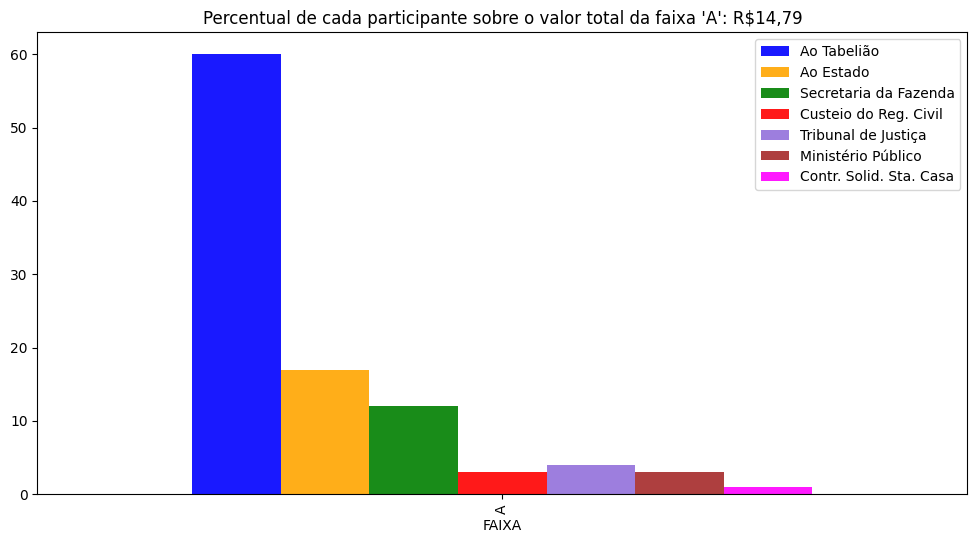

In [2937]:
dist_percentual_faixa.query("FAIXA == 'A'").plot.bar(color=['b', 'orange','g', 'red','mediumpurple', 'brown', 'magenta'],width=1, alpha=0.9, figsize=(12, 6))
plt.title("Percentual de cada participante sobre o valor total da faixa 'A': R$14,79")
plt.show()

In [2938]:
dados_limpos_percent = pd.DataFrame({
    'Ao Tabelião': dados_limpos['Ao Tabelião'] / dados_limpos['Total'] * 100,
    'Ao Estado': dados_limpos['Ao Estado'] / dados_limpos['Total'] * 100,
    'Secretaria da Fazenda': dados_limpos['Secretaria da Fazenda'] / dados_limpos['Total'] * 100,
    'Custeio do Reg. Civil': dados_limpos['Custeio do Reg. Civil']  / dados_limpos['Total'] * 100,
    'Tribunal de Justiça': dados_limpos['Tribunal de Justiça'] / dados_limpos['Total'] * 100,
    'Ministério Público': dados_limpos['Ministério Público'] / dados_limpos['Total'] * 100,
    'Contr. Solid. Sta. Casa': dados_limpos['Contr. Solid. Sta. Casa'] / dados_limpos['Total'] * 100,
    'Total': dados_limpos['Total']
})

In [2939]:
dist_num_percent = dados_limpos.iloc[0]

In [2940]:
novo_nome_coluna = "Faixa"
dist_num_percent = dist_num_percent.to_frame().T
antigo_nome_coluna = dist_num_percent.columns[1]
dist_num_percent = dist_num_percent.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [2941]:
dist_num_percent

,ID,Faixa,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Total
0,0,A,8.92,2.53,1.74,0.47,0.61,0.43,0.09,14.79


In [2942]:
dist_num_percent.to_csv("dist_num_percent.csv")

In [2943]:
dados_limpos_percent_faixas = dados_limpos_percent.drop(['Total'], axis=1).mean(axis=0)

In [2944]:
dados_limpos_percent_faixas

,0
Ao Tabelião,60.312927
Ao Estado,17.141211
Secretaria da Fazenda,11.733450
Custeio do Reg. Civil,3.174636
Tribunal de Justiça,4.139297
Ministério Público,2.895634
Contr. Solid. Sta. Casa,0.602845


In [2945]:
dados_colunas = [
    'Ao Tabelião', 'Ao Estado', 'Secretaria da Fazenda',
    'Custeio do Reg. Civil', 'Tribunal de Justiça',
    'Ministério Público', 'Contr. Solid. Sta. Casa'
]
percent_coluns = (dados_limpos.loc[dados_limpos['ID'] == 1, dados_colunas].iloc[0] / dados_limpos.loc[dados_limpos['ID'] == 1, 'Total'].iloc[0]) * 100

In [2946]:
percent_coluns

,1
Ao Tabelião,60.304288
Ao Estado,17.150761
Secretaria da Fazenda,11.721992
Custeio do Reg. Civil,3.181189
Tribunal de Justiça,4.149378
Ministério Público,2.904564
Contr. Solid. Sta. Casa,0.587828


In [2947]:
percent_coluns.to_csv("percent_coluns.csv", index=False, encoding='utf-8')

/tmp/ipykernel_684/1535037770.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


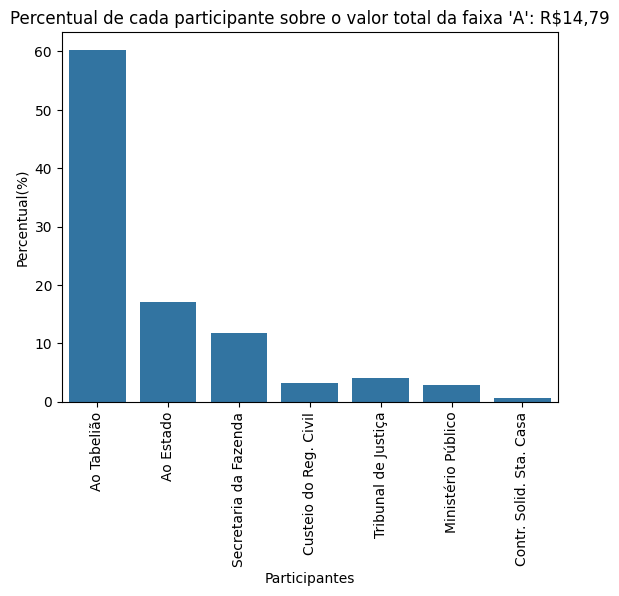

In [2948]:
df_percent = percent_coluns.reset_index()
df_percent.columns = ['Participantes', 'Percentual(%)']
ax = sns.barplot(data = df_percent, x="Participantes", y="Percentual(%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title("Percentual de cada participante sobre o valor total da faixa 'A': R$14,79")
plt.show()

In [2949]:
df_percent

,Participantes,Percentual(%)
0,Ao Tabelião,60.304288
1,Ao Estado,17.150761
2,Secretaria da Fazenda,11.721992
3,Custeio do Reg. Civil,3.181189
4,Tribunal de Justiça,4.149378
5,Ministério Público,2.904564
6,Contr. Solid. Sta. Casa,0.587828


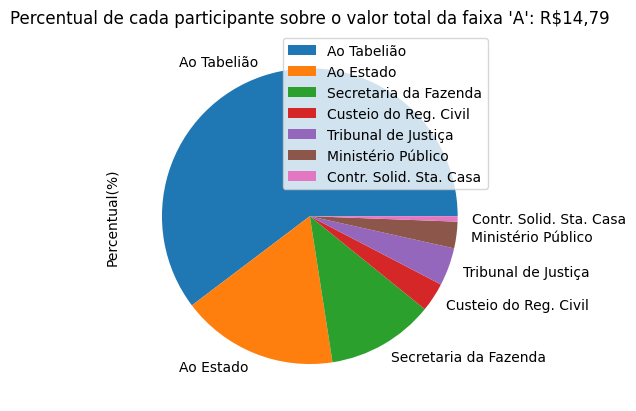

In [2950]:
df_percent.plot(kind="pie", y="Percentual(%)", labels=df_percent["Participantes"])
plt.title("Percentual de cada participante sobre o valor total da faixa 'A': R$14,79")
plt.show()

In [2951]:
df_outros_percent = df_percent.query("Participantes != 'Ao Tabelião'")

In [2952]:
df_outros_percent

,Participantes,Percentual(%)
1,Ao Estado,17.150761
2,Secretaria da Fazenda,11.721992
3,Custeio do Reg. Civil,3.181189
4,Tribunal de Justiça,4.149378
5,Ministério Público,2.904564
6,Contr. Solid. Sta. Casa,0.587828


In [2953]:
df_outros_percent.to_csv("df_outros_percent.csv", encoding='utf-8')

/tmp/ipykernel_684/101881905.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


[Text(0, 0, 'Ao Estado'),
 Text(1, 0, 'Secretaria da Fazenda'),
 Text(2, 0, 'Custeio do Reg. Civil'),
 Text(3, 0, 'Tribunal de Justiça'),
 Text(4, 0, 'Ministério Público'),
 Text(5, 0, 'Contr. Solid. Sta. Casa')]

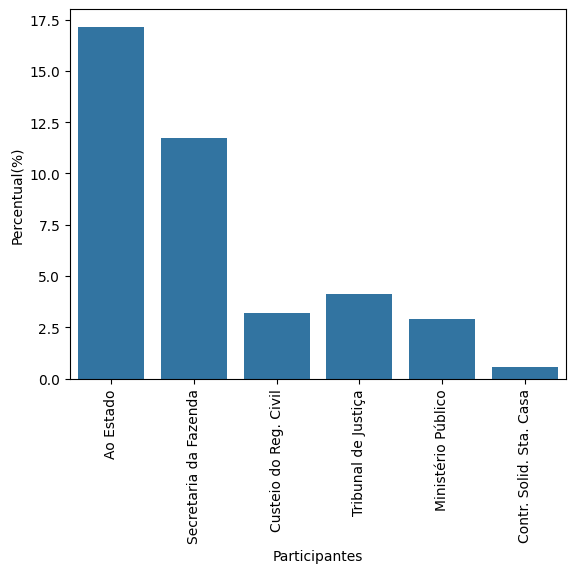

In [2954]:
ax = sns.barplot(data = df_percent.query("Participantes != 'Ao Tabelião'"),
                                     x="Participantes", y="Percentual(%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

In [2955]:
df_disferentes_Tab = df_percent.query("Participantes != 'Ao Tabelião'").sum()

In [2956]:
df_disferentes_Tab

,0
Participantes,Ao EstadoSecretaria da FazendaCusteio do Reg. ...
Percentual(%),39.695712


In [2957]:
df_total_disferentes_Tab = df_disferentes_Tab.loc['Percentual(%)']

In [2958]:
df_total_disferentes_Tab

np.float64(39.695712309820195)

In [2959]:
df_Tab = df_percent.query("Participantes == 'Ao Tabelião'").sum()

In [2960]:
df_Tab

,0
Participantes,Ao Tabelião
Percentual(%),60.304288


In [2961]:
df_total_tab = df_Tab.loc['Percentual(%)']

In [2962]:
df_total_tab

np.float64(60.304287690179805)

In [2963]:
df_total_geral = df_percent['Percentual(%)'].sum()

In [2964]:
df_total_geral

np.float64(100.0)

In [2965]:
print(df_total_tab, df_total_disferentes_Tab, df_total_geral)

60.304287690179805 39.695712309820195 100.0


In [2966]:
dados_tab_vs_outros = {
    "Participantes" : ["Ao Tabelião", "Outros"],
    "Percentual(%)" : [df_total_tab, df_total_disferentes_Tab]
}

In [2967]:
df_dados_tab_vs_outros = pd.DataFrame(dados_tab_vs_outros)

In [2968]:
df_dados_tab_vs_outros

,Participantes,Percentual(%)
0,Ao Tabelião,60.304288
1,Outros,39.695712


In [2969]:
tab_vs_outros_round = df_dados_tab_vs_outros.round()

In [2970]:
tab_vs_outros_round

,Participantes,Percentual(%)
0,Ao Tabelião,60.0
1,Outros,40.0


In [2971]:
df_dados_tab_vs_outros.to_csv("df_dados_tab_vs_outros.csv", index=False, encoding='utf-8')

In [2972]:
tab_vs_outros_round.to_csv("tab_vs_outros_round.csv", index=False, encoding='utf-8')

In [2973]:
sns.color_palette("mako")# Adicionar cores as paletas

[(0.18195582, 0.11955283, 0.23136943),
 (0.25307401, 0.23772973, 0.48316271),
 (0.21607792, 0.39736958, 0.61948028),
 (0.20344718, 0.56074869, 0.65649508),
 (0.25187832, 0.71827158, 0.67872193),
 (0.54578602, 0.8544913, 0.69848331)]

/tmp/ipykernel_684/1209223888.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_dados_tab_vs_outros, x="Participantes", y="Percentual(%)", palette="mako")


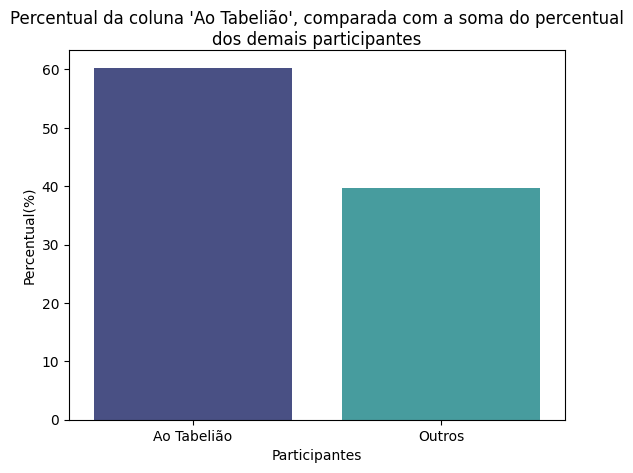

In [2974]:
sns.barplot(data = df_dados_tab_vs_outros, x="Participantes", y="Percentual(%)", palette="mako")
plt.title("Percentual da coluna 'Ao Tabelião', comparada com a soma do percentual dos demais participantes", wrap=True)
plt.show()

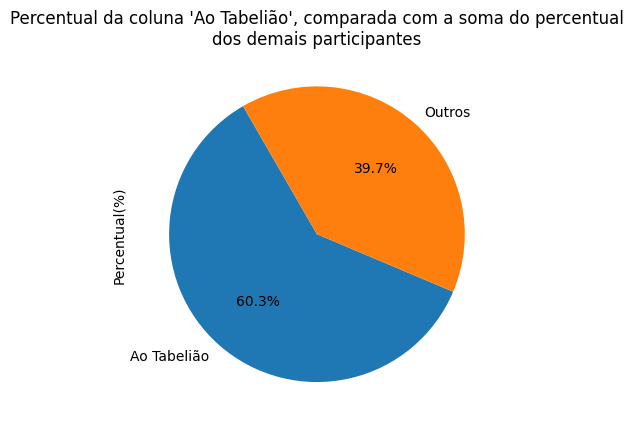

In [2975]:
df_dados_tab_vs_outros.plot(kind="pie", y="Percentual(%)", labels=df_dados_tab_vs_outros["Participantes"], autopct='%1.1f%%', startangle=120, legend=False)
plt.title("Percentual da coluna 'Ao Tabelião', comparada com a soma do percentual dos demais participantes", wrap=True)
plt.show()

/tmp/ipykernel_684/2938860920.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


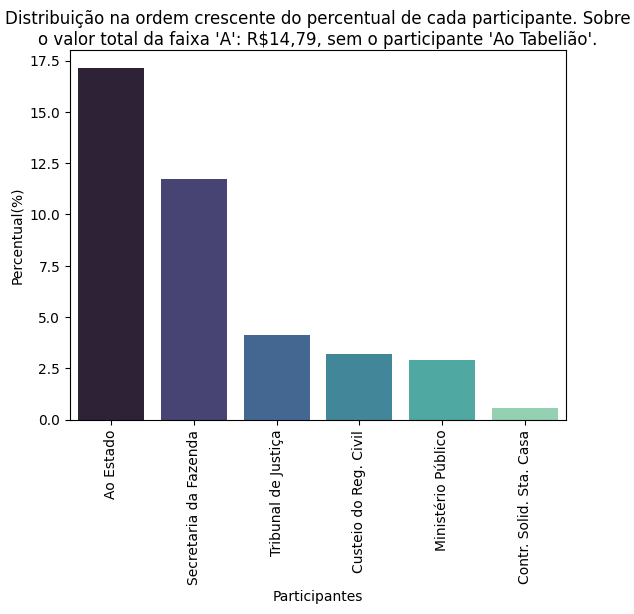

In [2976]:
ax = sns.barplot(data = df_percent.query("Participantes != 'Ao Tabelião'"),
            x="Participantes",
            y="Percentual(%)",
            palette="mako",
            hue="Participantes",
            hue_order=df_percent.query("Participantes != 'Ao Tabelião'").sort_values(by="Percentual(%)", ascending=False)['Participantes'].tolist(),
            order=df_percent.query("Participantes != 'Ao Tabelião'").sort_values(by="Percentual(%)", ascending=False)['Participantes'].tolist())
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title("Distribuição na ordem crescente do percentual de cada participante. Sobre o valor total da faixa 'A': R$14,79, sem o participante 'Ao Tabelião'.", wrap=True)
plt.show()

/tmp/ipykernel_684/3397421096.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


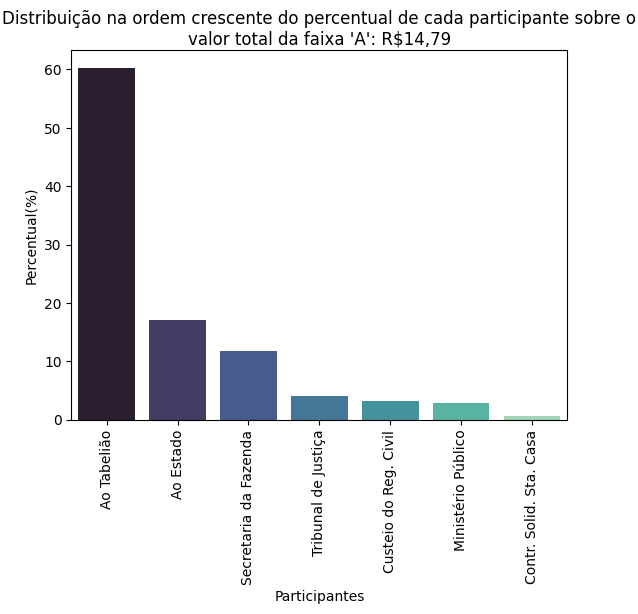

In [2977]:
df_percent = percent_coluns.reset_index()
df_percent.columns = ['Participantes', 'Percentual(%)']
ax = sns.barplot(data = df_percent, x="Participantes", y="Percentual(%)",
palette="mako",
hue="Participantes",
hue_order=df_percent.sort_values(by="Percentual(%)", ascending=False)['Participantes'].tolist(),
order=df_percent.sort_values(by="Percentual(%)", ascending=False)['Participantes'].tolist())
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title("Distribuição na ordem crescente do percentual de cada participante sobre o valor total da faixa 'A': R$14,79", wrap=True)
plt.show()

In [2978]:
sheet_id = '1ys07d1ElN3GaaetXJzzSwkBaFF-zQ--F'

In [2979]:
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet'

In [2980]:
outros_dados = pd.read_csv(url)

In [2981]:
outros_dados

,"Item 1 Pelo acolhimento do aceite ou devolução, recebimento do pagamento, desistência ou sustação judicial definitiva do protesto de titulo, documento de dívida ou indicação, apresentado a protesto, inclusos a apresentação, distribuição, protocolização, microfilmagem ou gravação eletrônica da imagem do título ou documento de dívida e o processamento de dados, intimação, além das despesas de tarifa postal, condução e edital: Valores básicos",Unnamed: 1,Discriminação,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Imposto ao Município,Total,Unnamed: 16
0,A,NaN,Até,NaN,NaN,NaN,"190,00","8,92","2,53","1,74","0,47","0,61","0,43","0,09",NaN,"14,79",NaN
1,B,NaN,Acima de,"190,00",NaN,até,"384,00","17,44","4,96","3,39","0,92","1,20","0,84","0,17",NaN,"28,92",NaN
2,C,NaN,Acima de,"384,00",NaN,até,"770,00","35,27","10,03","6,86","1,86","2,42","1,69","0,35",NaN,"58,48",NaN
3,D,NaN,Acima de,"770,00",NaN,até,"1.153,00","52,71","14,98","10,25","2,77","3,62","2,53","0,53",NaN,"87,39",NaN
4,E,NaN,Acima de,"1.153,00",NaN,até,"1.536,00","70,55","20,05","13,73","3,71","4,84","3,39","0,71",NaN,"116,98",NaN
5,F,NaN,Acima de,"1.536,00",NaN,até,"1.919,00","88,38","25,12","17,19","4,65","6,07","4,24","0,88",NaN,"146,53",NaN
6,G,NaN,Acima de,"1.919,00",NaN,até,"2.306,00","105,82","30,08","20,59","5,57","7,26","5,08","1,06",NaN,"175,46",NaN
7,H,NaN,Acima de,"2.306,00",NaN,até,"2.689,00","123,65","35,14","24,05","6,51","8,49","5,93","1,24",NaN,"205,01",NaN
8,I,NaN,Acima de,"2.689,00",NaN,até,"3.072,00","141,09","40,10","27,45","7,43","9,68","6,77","1,41",NaN,"233,93",NaN
9,J,NaN,Acima de,"3.072,00",NaN,até,"3.458,00","158,93","45,17","30,92","8,36","10,91","7,63","1,59",NaN,"263,51",NaN


In [2982]:
outros_dados.loc[33, outros_dados.columns[7:15]]

/usr/local/lib/python3.12/dist-packages/IPython/core/displayhook.py:275: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,33
Ao Tabelião,NaN
Ao Estado,NaN
Secretaria da Fazenda,NaN
Custeio do Reg. Civil,NaN
Tribunal de Justiça,NaN
Ministério Público,NaN
Contr. Solid. Sta. Casa,NaN
Imposto ao Município,NaN


In [2983]:
coluns30 = outros_dados.loc[30, outros_dados.columns[7:16]]#Item 3: a-1 por pessoa (5 anos):

In [2984]:
coluns30


,30
Ao Tabelião,"11,51"
Ao Estado,"3,27"
Secretaria da Fazenda,"2,24"
Custeio do Reg. Civil,"0,61"
Tribunal de Justiça,"0,79"
Ministério Público,"0,55"
Contr. Solid. Sta. Casa,"0,12"
Imposto ao Município,NaN
Total,"19,09"


In [2985]:
novo_nome_coluna = "Participante"
coluns30 = coluns30.reset_index()
antigo_nome_coluna = coluns30.columns[0]
coluns30 = coluns30.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [2986]:
novo_nome_coluna = "Emolumentos"
antigo_nome_coluna = 30
coluns30 = coluns30.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [2987]:
def format_brazilian_currency(x):
    if pd.isna(x):
        return ""

    valor_formatado = f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor_formatado}"

colunas_para_limpas_e_formatar = ['Emolumentos']

for col in colunas_para_limpas_e_formatar:
    if col in coluns30.columns:

        coluns30[col] = coluns30[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        coluns30[col] = pd.to_numeric(coluns30[col], errors='coerce')


formatados = {col: format_brazilian_currency for col in colunas_para_limpas_e_formatar if col in coluns30.columns}

coluns30 = coluns30.style.format(formatados)

In [2988]:
coluns30 = coluns30.data.reset_index(names='id')

In [2989]:
coluns30

,id,Participante,Emolumentos
0,0,Ao Tabelião,11.51
1,1,Ao Estado,3.27
2,2,Secretaria da Fazenda,2.24
3,3,Custeio do Reg. Civil,0.61
4,4,Tribunal de Justiça,0.79
5,5,Ministério Público,0.55
6,6,Contr. Solid. Sta. Casa,0.12
7,7,Imposto ao Município,NaN
8,8,Total,19.09


In [2990]:
coluns30.to_excel('coluns30.xlsx', index=False)

In [2991]:
valor = coluns30[coluns30["id"] == 8].index
coluns30b = coluns30.drop(index=valor)

In [2992]:
coluns30b.to_excel('coluns30b.xlsx', index=False)

In [2993]:
coluns30b

,id,Participante,Emolumentos
0,0,Ao Tabelião,11.51
1,1,Ao Estado,3.27
2,2,Secretaria da Fazenda,2.24
3,3,Custeio do Reg. Civil,0.61
4,4,Tribunal de Justiça,0.79
5,5,Ministério Público,0.55
6,6,Contr. Solid. Sta. Casa,0.12
7,7,Imposto ao Município,NaN


In [2994]:
coluns31 = outros_dados.loc[31, outros_dados.columns[7:16]] #Item 3: a-1.1 - por pessoa (10 anos):

In [2995]:
coluns31

,31
Ao Tabelião,"23,03"
Ao Estado,"6,54"
Secretaria da Fazenda,"4,48"
Custeio do Reg. Civil,"1,21"
Tribunal de Justiça,"1,58"
Ministério Público,"1,11"
Contr. Solid. Sta. Casa,"0,23"
Imposto ao Município,NaN
Total,"38,18"


In [2996]:
novo_nome_coluna = "Participante"
coluns31 = coluns31.reset_index()
antigo_nome_coluna = coluns31.columns[0]
coluns31 = coluns31.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [2997]:
novo_nome_coluna = "Emolumentos"
antigo_nome_coluna = 31
coluns31 = coluns31.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [2998]:
def format_brazilian_currency(x):
    if pd.isna(x):
        return ""

    valor_formatado = f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor_formatado}"

colunas_para_limpas_e_formatar = ['Emolumentos']

for col in colunas_para_limpas_e_formatar:
    if col in coluns31.columns:

        coluns31[col] = coluns31[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        coluns31[col] = pd.to_numeric(coluns31[col], errors='coerce')


formatados = {col: format_brazilian_currency for col in colunas_para_limpas_e_formatar if col in coluns31.columns}

coluns31 = coluns31.style.format(formatados)

In [2999]:
coluns31 = coluns31.data.reset_index(names='id')

In [3000]:
coluns31

,id,Participante,Emolumentos
0,0,Ao Tabelião,23.03
1,1,Ao Estado,6.54
2,2,Secretaria da Fazenda,4.48
3,3,Custeio do Reg. Civil,1.21
4,4,Tribunal de Justiça,1.58
5,5,Ministério Público,1.11
6,6,Contr. Solid. Sta. Casa,0.23
7,7,Imposto ao Município,NaN
8,8,Total,38.18


In [3001]:
coluns31.to_excel('coluns31.xlsx', index=False)

In [3002]:
valor = coluns31[coluns31["id"] == 8].index
coluns31b = coluns31.drop(index=valor)

In [3003]:
coluns31b.to_excel('coluns31b.xlsx', index=False)

In [3004]:
coluns31b

,id,Participante,Emolumentos
0,0,Ao Tabelião,23.03
1,1,Ao Estado,6.54
2,2,Secretaria da Fazenda,4.48
3,3,Custeio do Reg. Civil,1.21
4,4,Tribunal de Justiça,1.58
5,5,Ministério Público,1.11
6,6,Contr. Solid. Sta. Casa,0.23
7,7,Imposto ao Município,NaN


In [3005]:
coluns34 = outros_dados.loc[34, outros_dados.columns[7:16]] #Item 3: a-2 quando expedida para atendimento de convên...

In [3006]:
coluns34

,34
Ao Tabelião,"3,32"
Ao Estado,"0,94"
Secretaria da Fazenda,"0,65"
Custeio do Reg. Civil,"0,17"
Tribunal de Justiça,"0,23"
Ministério Público,"0,16"
Contr. Solid. Sta. Casa,"0,03"
Imposto ao Município,NaN
Total,"5,50"


In [3007]:
novo_nome_coluna = "Participante"
coluns34 = coluns34.reset_index()
antigo_nome_coluna = coluns34.columns[0]
coluns34 = coluns34.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3008]:
novo_nome_coluna = "Emolumentos"
antigo_nome_coluna = 34
coluns34 = coluns34.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3009]:
def format_brazilian_currency(x):
    if pd.isna(x):
        return ""

    valor_formatado = f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor_formatado}"

colunas_para_limpas_e_formatar = ['Emolumentos']

for col in colunas_para_limpas_e_formatar:
    if col in coluns34.columns:

        coluns34[col] = coluns34[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        coluns34[col] = pd.to_numeric(coluns34[col], errors='coerce')


formatados = {col: format_brazilian_currency for col in colunas_para_limpas_e_formatar if col in coluns34.columns}

coluns34 = coluns34.style.format(formatados)

In [3010]:
coluns34

,Participante,Emolumentos
0,Ao Tabelião,"3,32"
1,Ao Estado,"0,94"
2,Secretaria da Fazenda,"0,65"
3,Custeio do Reg. Civil,"0,17"
4,Tribunal de Justiça,"0,23"
5,Ministério Público,"0,16"
6,Contr. Solid. Sta. Casa,"0,03"
7,Imposto ao Município,
8,Total,"5,50"


In [3011]:
coluns34 = coluns34.data.reset_index(names='id')

In [3012]:
coluns34

,id,Participante,Emolumentos
0,0,Ao Tabelião,3.32
1,1,Ao Estado,0.94
2,2,Secretaria da Fazenda,0.65
3,3,Custeio do Reg. Civil,0.17
4,4,Tribunal de Justiça,0.23
5,5,Ministério Público,0.16
6,6,Contr. Solid. Sta. Casa,0.03
7,7,Imposto ao Município,NaN
8,8,Total,5.50


In [3013]:
coluns34.to_excel('coluns34.xlsx', index=False)

In [3014]:
valor = coluns34[coluns34["id"] == 8].index
coluns34b = coluns34.drop(index=valor)

In [3015]:
coluns34b.to_excel('coluns34b.xlsx', index=False)

In [3016]:
coluns34b

,id,Participante,Emolumentos
0,0,Ao Tabelião,3.32
1,1,Ao Estado,0.94
2,2,Secretaria da Fazenda,0.65
3,3,Custeio do Reg. Civil,0.17
4,4,Tribunal de Justiça,0.23
5,5,Ministério Público,0.16
6,6,Contr. Solid. Sta. Casa,0.03
7,7,Imposto ao Município,NaN


In [3017]:
coluns37 = outros_dados.loc[37, outros_dados.columns[7:16]]#Item 3: b -1 pela certidão fornecida à cada entidade

In [3018]:
coluns37

,37
Ao Tabelião,"11,51"
Ao Estado,"3,27"
Secretaria da Fazenda,"2,24"
Custeio do Reg. Civil,"0,61"
Tribunal de Justiça,"0,79"
Ministério Público,"0,55"
Contr. Solid. Sta. Casa,"0,12"
Imposto ao Município,NaN
Total,"19,09"


In [3019]:
novo_nome_coluna = "Participante"
coluns37 = coluns37.reset_index()
antigo_nome_coluna = coluns37.columns[0]
coluns37 = coluns37.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3020]:
novo_nome_coluna = "Emolumentos"
antigo_nome_coluna = 37
coluns37 = coluns37.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3021]:
def format_brazilian_currency(x):
    if pd.isna(x):
        return ""

    valor_formatado = f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor_formatado}"

colunas_para_limpas_e_formatar = ['Emolumentos']

for col in colunas_para_limpas_e_formatar:
    if col in coluns37.columns:

        coluns37[col] = coluns37[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        coluns37[col] = pd.to_numeric(coluns37[col], errors='coerce')


formatados = {col: format_brazilian_currency for col in colunas_para_limpas_e_formatar if col in coluns37.columns}

coluns37 = coluns37.style.format(formatados)

In [3022]:
coluns37 = coluns37.data.reset_index(names='id')

In [3023]:
coluns37

,id,Participante,Emolumentos
0,0,Ao Tabelião,11.51
1,1,Ao Estado,3.27
2,2,Secretaria da Fazenda,2.24
3,3,Custeio do Reg. Civil,0.61
4,4,Tribunal de Justiça,0.79
5,5,Ministério Público,0.55
6,6,Contr. Solid. Sta. Casa,0.12
7,7,Imposto ao Município,NaN
8,8,Total,19.09


In [3024]:
coluns37.to_excel('coluns37.xlsx', index=False)

In [3025]:
valor = coluns37[coluns37["id"] == 8].index
coluns37b = coluns37.drop(index=valor)

In [3026]:
coluns37b.to_excel('coluns37b.xlsx', index=False)

In [3027]:
coluns37b

,id,Participante,Emolumentos
0,0,Ao Tabelião,11.51
1,1,Ao Estado,3.27
2,2,Secretaria da Fazenda,2.24
3,3,Custeio do Reg. Civil,0.61
4,4,Tribunal de Justiça,0.79
5,5,Ministério Público,0.55
6,6,Contr. Solid. Sta. Casa,0.12
7,7,Imposto ao Município,NaN


In [3028]:
coluns39 = outros_dados.loc[39, outros_dados.columns[7:16]]#Item 3: b - 2 a cada nome e documento do protesto, do ...

In [3029]:
coluns39

,39
Ao Tabelião,"2,08"
Ao Estado,"0,59"
Secretaria da Fazenda,"0,41"
Custeio do Reg. Civil,"0,11"
Tribunal de Justiça,"0,14"
Ministério Público,"0,10"
Contr. Solid. Sta. Casa,"0,02"
Imposto ao Município,NaN
Total,"3,45"


In [3030]:
novo_nome_coluna = "Participante"
coluns39 = coluns39.reset_index()
antigo_nome_coluna = coluns39.columns[0]
coluns39 = coluns39.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3031]:
novo_nome_coluna = "Emolumentos"
antigo_nome_coluna = 39
coluns39 = coluns39.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3032]:
def format_brazilian_currency(x):
    if pd.isna(x):
        return ""

    valor_formatado = f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor_formatado}"

colunas_para_limpas_e_formatar = ['Emolumentos']

for col in colunas_para_limpas_e_formatar:
    if col in coluns39.columns:

        coluns39[col] = coluns39[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        coluns39[col] = pd.to_numeric(coluns39[col], errors='coerce')


formatados = {col: format_brazilian_currency for col in colunas_para_limpas_e_formatar if col in coluns39.columns}

coluns39 = coluns39.style.format(formatados)

In [3033]:
coluns39 = coluns39.data.reset_index(names='id')

In [3034]:
coluns39

,id,Participante,Emolumentos
0,0,Ao Tabelião,2.08
1,1,Ao Estado,0.59
2,2,Secretaria da Fazenda,0.41
3,3,Custeio do Reg. Civil,0.11
4,4,Tribunal de Justiça,0.14
5,5,Ministério Público,0.10
6,6,Contr. Solid. Sta. Casa,0.02
7,7,Imposto ao Município,NaN
8,8,Total,3.45


In [3035]:
coluns39.to_excel('coluns39.xlsx', index=False)

In [3036]:
valor = coluns39[coluns39["id"] == 8].index
coluns39b = coluns39.drop(index=valor)

In [3037]:
coluns39b.to_excel('coluns39b.xlsx', index=False)

In [3038]:
coluns39b

,id,Participante,Emolumentos
0,0,Ao Tabelião,2.08
1,1,Ao Estado,0.59
2,2,Secretaria da Fazenda,0.41
3,3,Custeio do Reg. Civil,0.11
4,4,Tribunal de Justiça,0.14
5,5,Ministério Público,0.10
6,6,Contr. Solid. Sta. Casa,0.02
7,7,Imposto ao Município,NaN


In [3039]:
coluns41 = outros_dados.loc[41, outros_dados.columns[7:16]]#Item 4: Xerocópia ou fotocópia de documento lavrado ou..

In [3040]:
coluns41

,41
Ao Tabelião,"1,86"
Ao Estado,"0,53"
Secretaria da Fazenda,"0,36"
Custeio do Reg. Civil,"0,10"
Tribunal de Justiça,"0,13"
Ministério Público,"0,09"
Contr. Solid. Sta. Casa,"0,02"
Imposto ao Município,NaN
Total,"3,09"


In [3041]:
novo_nome_coluna = "Participante"
coluns41 = coluns41.reset_index() # Convert Series to DataFrame, making the index a column
antigo_nome_coluna = coluns41.columns[0]
coluns41 = coluns41.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3042]:
novo_nome_coluna = "Emolumentos"
antigo_nome_coluna = 41
coluns41 = coluns41.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3043]:
def format_brazilian_currency(x):
    if pd.isna(x):
        return ""

    valor_formatado = f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor_formatado}"

colunas_para_limpas_e_formatar = ['Emolumentos']

for col in colunas_para_limpas_e_formatar:
    if col in coluns41.columns:

        coluns41[col] = coluns41[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        coluns41[col] = pd.to_numeric(coluns41[col], errors='coerce')


formatados = {col: format_brazilian_currency for col in colunas_para_limpas_e_formatar if col in coluns41.columns}

coluns41 = coluns41.style.format(formatados)

In [3044]:
coluns41

,Participante,Emolumentos
0,Ao Tabelião,"1,86"
1,Ao Estado,"0,53"
2,Secretaria da Fazenda,"0,36"
3,Custeio do Reg. Civil,"0,10"
4,Tribunal de Justiça,"0,13"
5,Ministério Público,"0,09"
6,Contr. Solid. Sta. Casa,"0,02"
7,Imposto ao Município,
8,Total,"3,09"


In [3045]:
coluns41 = coluns41.data.reset_index(names='id')

In [3046]:
coluns41

,id,Participante,Emolumentos
0,0,Ao Tabelião,1.86
1,1,Ao Estado,0.53
2,2,Secretaria da Fazenda,0.36
3,3,Custeio do Reg. Civil,0.10
4,4,Tribunal de Justiça,0.13
5,5,Ministério Público,0.09
6,6,Contr. Solid. Sta. Casa,0.02
7,7,Imposto ao Município,NaN
8,8,Total,3.09


In [3047]:
coluns41.to_excel('coluns41.xlsx', index=False)

In [3048]:
valor = coluns41[coluns41["id"] == 8].index
coluns41b = coluns41.drop(index=valor)

In [3049]:
coluns41b.to_excel('coluns41b.xlsx', index=False)

In [3050]:
coluns41b

,id,Participante,Emolumentos
0,0,Ao Tabelião,1.86
1,1,Ao Estado,0.53
2,2,Secretaria da Fazenda,0.36
3,3,Custeio do Reg. Civil,0.10
4,4,Tribunal de Justiça,0.13
5,5,Ministério Público,0.09
6,6,Contr. Solid. Sta. Casa,0.02
7,7,Imposto ao Município,NaN


In [3051]:
coluns43 = outros_dados.loc[43, outros_dados.columns[7:16]]#Item 5: cópia de documento microfilmado ou gravado ele.

In [3052]:
coluns43

,43
Ao Tabelião,"17,44"
Ao Estado,"4,96"
Secretaria da Fazenda,"3,39"
Custeio do Reg. Civil,"0,92"
Tribunal de Justiça,"1,20"
Ministério Público,"0,84"
Contr. Solid. Sta. Casa,"0,17"
Imposto ao Município,NaN
Total,"28,92"


In [3053]:
novo_nome_coluna = "Participante"
coluns43 = coluns43.reset_index()
antigo_nome_coluna = coluns43.columns[0]
coluns43 = coluns43.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3054]:
novo_nome_coluna = "Emolumentos"
antigo_nome_coluna = 43
coluns43 = coluns43.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3055]:
def format_brazilian_currency(x):
    if pd.isna(x):
        return ""

    valor_formatado = f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor_formatado}"

colunas_para_limpas_e_formatar = ['Emolumentos']

for col in colunas_para_limpas_e_formatar:
    if col in coluns43.columns:

        coluns43[col] = coluns43[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        coluns43[col] = pd.to_numeric(coluns43[col], errors='coerce')


formatados = {col: format_brazilian_currency for col in colunas_para_limpas_e_formatar if col in coluns43.columns}

coluns43 = coluns43.style.format(formatados)

In [3056]:
coluns43 = coluns43.data.reset_index(names='id')

In [3057]:
coluns43

,id,Participante,Emolumentos
0,0,Ao Tabelião,17.44
1,1,Ao Estado,4.96
2,2,Secretaria da Fazenda,3.39
3,3,Custeio do Reg. Civil,0.92
4,4,Tribunal de Justiça,1.20
5,5,Ministério Público,0.84
6,6,Contr. Solid. Sta. Casa,0.17
7,7,Imposto ao Município,NaN
8,8,Total,28.92


In [3058]:
coluns43.to_excel('coluns43.xlsx', index=False)

In [3059]:
valor = coluns43[coluns43["id"] == 8].index
coluns43b = coluns43.drop(index=valor)


In [3060]:
coluns43b.to_excel('coluns43b.xlsx', index=False)

In [3061]:
coluns43b

,id,Participante,Emolumentos
0,0,Ao Tabelião,17.44
1,1,Ao Estado,4.96
2,2,Secretaria da Fazenda,3.39
3,3,Custeio do Reg. Civil,0.92
4,4,Tribunal de Justiça,1.20
5,5,Ministério Público,0.84
6,6,Contr. Solid. Sta. Casa,0.17
7,7,Imposto ao Município,NaN


In [3062]:
coluns45 = outros_dados.loc[45, outros_dados.columns[7:16]]#Item 6: Busca em arquivo de procurações, de credencia..

In [3063]:
coluns45

,45
Ao Tabelião,"0,73"
Ao Estado,"0,21"
Secretaria da Fazenda,"0,14"
Custeio do Reg. Civil,"0,04"
Tribunal de Justiça,"0,05"
Ministério Público,"0,03"
Contr. Solid. Sta. Casa,"0,01"
Imposto ao Município,NaN
Total,"1,21"


In [3064]:
novo_nome_coluna = "Participante"
coluns45 = coluns45.reset_index()
antigo_nome_coluna = coluns45.columns[0]
coluns45 = coluns45.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3065]:
novo_nome_coluna = "Emolumentos"
antigo_nome_coluna = 45
coluns45 = coluns45.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3066]:
coluns45

,Participante,Emolumentos
0,Ao Tabelião,"0,73"
1,Ao Estado,"0,21"
2,Secretaria da Fazenda,"0,14"
3,Custeio do Reg. Civil,"0,04"
4,Tribunal de Justiça,"0,05"
5,Ministério Público,"0,03"
6,Contr. Solid. Sta. Casa,"0,01"
7,Imposto ao Município,NaN
8,Total,"1,21"


In [3067]:
def format_brazilian_currency(x):
    if pd.isna(x):
        return ""

    valor_formatado = f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor_formatado}"

colunas_para_limpas_e_formatar = ['Emolumentos']

for col in colunas_para_limpas_e_formatar:
    if col in coluns45.columns:

        coluns45[col] = coluns45[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        coluns45[col] = pd.to_numeric(coluns45[col], errors='coerce')


formatados = {col: format_brazilian_currency for col in colunas_para_limpas_e_formatar if col in coluns45.columns}

coluns45 = coluns45.style.format(formatados)

In [3068]:
coluns45 = coluns45.data.reset_index(names='id')

In [3069]:
coluns45

,id,Participante,Emolumentos
0,0,Ao Tabelião,0.73
1,1,Ao Estado,0.21
2,2,Secretaria da Fazenda,0.14
3,3,Custeio do Reg. Civil,0.04
4,4,Tribunal de Justiça,0.05
5,5,Ministério Público,0.03
6,6,Contr. Solid. Sta. Casa,0.01
7,7,Imposto ao Município,NaN
8,8,Total,1.21


In [3070]:
coluns45.to_excel('coluns45.xlsx', index=False)

In [3071]:
valor = coluns45[coluns45["id"] == 8].index
coluns45b = coluns45.drop(index=valor)


In [3072]:
coluns45b.to_excel('coluns45b.xlsx', index=False)

In [3073]:
coluns45b

,id,Participante,Emolumentos
0,0,Ao Tabelião,0.73
1,1,Ao Estado,0.21
2,2,Secretaria da Fazenda,0.14
3,3,Custeio do Reg. Civil,0.04
4,4,Tribunal de Justiça,0.05
5,5,Ministério Público,0.03
6,6,Contr. Solid. Sta. Casa,0.01
7,7,Imposto ao Município,NaN


In [3074]:
coluns47 = outros_dados.loc[47, outros_dados.columns[7:16]]#Item: 7: Buscas outras, que não sejam para fornecimento.

In [3075]:
coluns47

,47
Ao Tabelião,"0,73"
Ao Estado,"0,21"
Secretaria da Fazenda,"0,14"
Custeio do Reg. Civil,"0,04"
Tribunal de Justiça,"0,05"
Ministério Público,"0,03"
Contr. Solid. Sta. Casa,"0,01"
Imposto ao Município,NaN
Total,"1,21"


In [3076]:
novo_nome_coluna = "Participante"
coluns47 = coluns47.reset_index()
antigo_nome_coluna = coluns47.columns[0]
coluns47 = coluns47.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3077]:
novo_nome_coluna = "Emolumentos"
antigo_nome_coluna = 47
coluns47 = coluns47.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3078]:
def format_brazilian_currency(x):
    if pd.isna(x):
        return ""

    valor_formatado = f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor_formatado}"

colunas_para_limpas_e_formatar = ['Emolumentos']

for col in colunas_para_limpas_e_formatar:
    if col in coluns47.columns:

        coluns47[col] = coluns47[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        coluns47[col] = pd.to_numeric(coluns47[col], errors='coerce')


formatados = {col: format_brazilian_currency for col in colunas_para_limpas_e_formatar if col in coluns47.columns}

coluns47 = coluns47.style.format(formatados)

In [3079]:
coluns47 = coluns47.data.reset_index(names='id')

In [3080]:
coluns47.to_excel('coluns47.xlsx', index=False)

In [3081]:
coluns47

,id,Participante,Emolumentos
0,0,Ao Tabelião,0.73
1,1,Ao Estado,0.21
2,2,Secretaria da Fazenda,0.14
3,3,Custeio do Reg. Civil,0.04
4,4,Tribunal de Justiça,0.05
5,5,Ministério Público,0.03
6,6,Contr. Solid. Sta. Casa,0.01
7,7,Imposto ao Município,NaN
8,8,Total,1.21


In [3082]:
valor = coluns47[coluns47["id"] == 8].index
coluns47b = coluns47.drop(index=valor)


In [3083]:
coluns47b.to_excel('coluns47b.xlsx', index=False)

In [3084]:
coluns47b

,id,Participante,Emolumentos
0,0,Ao Tabelião,0.73
1,1,Ao Estado,0.21
2,2,Secretaria da Fazenda,0.14
3,3,Custeio do Reg. Civil,0.04
4,4,Tribunal de Justiça,0.05
5,5,Ministério Público,0.03
6,6,Contr. Solid. Sta. Casa,0.01
7,7,Imposto ao Município,NaN


In [3085]:
coluns49 = outros_dados.loc[49, outros_dados.columns[7:16]]#Item 8:

In [3086]:
coluns49

,49
Ao Tabelião,"1,15"
Ao Estado,"0,33"
Secretaria da Fazenda,"0,22"
Custeio do Reg. Civil,"0,06"
Tribunal de Justiça,"0,08"
Ministério Público,"0,05"
Contr. Solid. Sta. Casa,"0,01"
Imposto ao Município,NaN
Total,"1,90"


In [3087]:
novo_nome_coluna = "Participante"
coluns49 = coluns49.reset_index()
antigo_nome_coluna = coluns49.columns[0]
coluns49 = coluns49.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3088]:
novo_nome_coluna = "Emolumentos"
antigo_nome_coluna = 49
coluns49 = coluns49.rename(columns={antigo_nome_coluna: novo_nome_coluna})

In [3089]:
def format_brazilian_currency(x):
    if pd.isna(x):
        return ""

    valor_formatado = f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor_formatado}"

colunas_para_limpas_e_formatar = ['Emolumentos']

for col in colunas_para_limpas_e_formatar:
    if col in coluns49.columns:

        coluns49[col] = coluns49[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        coluns49[col] = pd.to_numeric(coluns49[col], errors='coerce')


formatados = {col: format_brazilian_currency for col in colunas_para_limpas_e_formatar if col in coluns49.columns}

coluns49 = coluns49.style.format(formatados)

In [3090]:
coluns49 = coluns49.data.reset_index(names='id')

In [3091]:
coluns49.to_excel('coluns49.xlsx', index=False)

In [3092]:
coluns49

,id,Participante,Emolumentos
0,0,Ao Tabelião,1.15
1,1,Ao Estado,0.33
2,2,Secretaria da Fazenda,0.22
3,3,Custeio do Reg. Civil,0.06
4,4,Tribunal de Justiça,0.08
5,5,Ministério Público,0.05
6,6,Contr. Solid. Sta. Casa,0.01
7,7,Imposto ao Município,NaN
8,8,Total,1.90


In [3093]:
valor = coluns49[coluns49["id"] == 8].index
coluns49b = coluns49.drop(index=valor)

In [3094]:
coluns49b.to_excel('coluns49b.xlsx', index=False)

In [3095]:
coluns49b

,id,Participante,Emolumentos
0,0,Ao Tabelião,1.15
1,1,Ao Estado,0.33
2,2,Secretaria da Fazenda,0.22
3,3,Custeio do Reg. Civil,0.06
4,4,Tribunal de Justiça,0.08
5,5,Ministério Público,0.05
6,6,Contr. Solid. Sta. Casa,0.01
7,7,Imposto ao Município,NaN


In [3096]:
idices_dados = outros_dados.loc[26:49, outros_dados.columns[0:2]]

In [3097]:
idices_dados

,"Item 1 Pelo acolhimento do aceite ou devolução, recebimento do pagamento, desistência ou sustação judicial definitiva do protesto de titulo, documento de dívida ou indicação, apresentado a protesto, inclusos a apresentação, distribuição, protocolização, microfilmagem ou gravação eletrônica da imagem do título ou documento de dívida e o processamento de dados, intimação, além das despesas de tarifa postal, condução e edital: Valores básicos",Unnamed: 1
26,2 Pelo protesto lavrado e o cancelame...,NaN
27,3,"Certidão, inclusa a busca, quando houver:"
28,a,"de apontamento, positiva ou negativa de protes..."
29,NaN,a-1 por pessoa (5 anos):
30,NaN,NaN
31,NaN,NaN
32,a-1.1 - por pessoa (10 anos):,NaN
33,a-2 quando expedida para atendimento de convên...,NaN
34,NaN,NaN
35,b,"sob forma de relação para entidades privadas, ..."


In [3098]:
idices_dados = idices_dados.style.set_properties(**{'text-align': 'left'})

In [3099]:
idices_dados

,"Item 1 Pelo acolhimento do aceite ou devolução, recebimento do pagamento, desistência ou sustação judicial definitiva do protesto de titulo, documento de dívida ou indicação, apresentado a protesto, inclusos a apresentação, distribuição, protocolização, microfilmagem ou gravação eletrônica da imagem do título ou documento de dívida e o processamento de dados, intimação, além das despesas de tarifa postal, condução e edital: Valores básicos",Unnamed: 1
26,"2 Pelo protesto lavrado e o cancelamento definitivo do registro ou dos seus efeitos, inclusos a apresentação, distribuição, protocolização, microfilmagem ou gravação eletrônica da imagem dos documentos e o processamento de dados, inclusive do protesto, a intimação, de título, documento de dívida ou indicação são devidos os emolumentos previstos no item 1, acrescidos de 50% (cinquenta por cento), além das despesas de remessa postal, condução e publicação de edital.",nan
27,3,"Certidão, inclusa a busca, quando houver:"
28,a,"de apontamento, positiva ou negativa de protesto, de cancelamento ou de sustação de seus efeitos, negativa de homônimo, individual ou ou sob forma de relação para entidade de classe, independente do número de páginas, a cada período de 5 (cinco) anos:"
29,nan,a-1 por pessoa (5 anos):
30,nan,nan
31,nan,nan
32,a-1.1 - por pessoa (10 anos):,nan
33,"a-2 quando expedida para atendimento de convênio firmado entre o governo Federal, Estadual ou Municipal e a entidade representativa dos Tabeliães de Protesto de Títulos, destinada a programas",nan
34,nan,nan
35,b,"sob forma de relação para entidades privadas, representativas da indústria e do comércio ou àquelas vinculadas à proteção do cré dito, de fornecimento diário, de protestos lavrados ou de"


In [3100]:
idices_dados = idices_dados.data.fillna('').style.set_properties(**{'text-align': 'left'})

In [3101]:
idices_dados

,"Item 1 Pelo acolhimento do aceite ou devolução, recebimento do pagamento, desistência ou sustação judicial definitiva do protesto de titulo, documento de dívida ou indicação, apresentado a protesto, inclusos a apresentação, distribuição, protocolização, microfilmagem ou gravação eletrônica da imagem do título ou documento de dívida e o processamento de dados, intimação, além das despesas de tarifa postal, condução e edital: Valores básicos",Unnamed: 1
26,"2 Pelo protesto lavrado e o cancelamento definitivo do registro ou dos seus efeitos, inclusos a apresentação, distribuição, protocolização, microfilmagem ou gravação eletrônica da imagem dos documentos e o processamento de dados, inclusive do protesto, a intimação, de título, documento de dívida ou indicação são devidos os emolumentos previstos no item 1, acrescidos de 50% (cinquenta por cento), além das despesas de remessa postal, condução e publicação de edital.",
27,3,"Certidão, inclusa a busca, quando houver:"
28,a,"de apontamento, positiva ou negativa de protesto, de cancelamento ou de sustação de seus efeitos, negativa de homônimo, individual ou ou sob forma de relação para entidade de classe, independente do número de páginas, a cada período de 5 (cinco) anos:"
29,,a-1 por pessoa (5 anos):
30,,
31,,
32,a-1.1 - por pessoa (10 anos):,
33,"a-2 quando expedida para atendimento de convênio firmado entre o governo Federal, Estadual ou Municipal e a entidade representativa dos Tabeliães de Protesto de Títulos, destinada a programas",
34,,
35,b,"sob forma de relação para entidades privadas, representativas da indústria e do comércio ou àquelas vinculadas à proteção do cré dito, de fornecimento diário, de protestos lavrados ou de"


In [3102]:
import pandas as pd

if isinstance(idices_dados, pd.io.formats.style.Styler):
    idices_dados = idices_dados.data

col1_name = idices_dados.columns[0]
col2_name = idices_dados.columns[1]

idices_dados['Item'] = idices_dados[col1_name].fillna('').astype(str).str.cat(idices_dados[col2_name].fillna('').astype(str), sep=' ')


In [3103]:
idices_dados

,"Item 1 Pelo acolhimento do aceite ou devolução, recebimento do pagamento, desistência ou sustação judicial definitiva do protesto de titulo, documento de dívida ou indicação, apresentado a protesto, inclusos a apresentação, distribuição, protocolização, microfilmagem ou gravação eletrônica da imagem do título ou documento de dívida e o processamento de dados, intimação, além das despesas de tarifa postal, condução e edital: Valores básicos",Unnamed: 1,Item
26,2 Pelo protesto lavrado e o cancelame...,,2 Pelo protesto lavrado e o cancelame...
27,3,"Certidão, inclusa a busca, quando houver:","3 Certidão, inclusa a busca, quando houver:"
28,a,"de apontamento, positiva ou negativa de protes...","a de apontamento, positiva ou negativa de prot..."
29,,a-1 por pessoa (5 anos):,a-1 por pessoa (5 anos):
30,,,
31,,,
32,a-1.1 - por pessoa (10 anos):,,a-1.1 - por pessoa (10 anos):
33,a-2 quando expedida para atendimento de convên...,,a-2 quando expedida para atendimento de convên...
34,,,
35,b,"sob forma de relação para entidades privadas, ...",b sob forma de relação para entidades privadas...


In [3104]:
idices_dados = idices_dados.drop(columns=[idices_dados.columns[0],'Unnamed: 1'])

In [3105]:
idices_dados

,Item
26,2 Pelo protesto lavrado e o cancelame...
27,"3 Certidão, inclusa a busca, quando houver:"
28,"a de apontamento, positiva ou negativa de prot..."
29,a-1 por pessoa (5 anos):
30,
31,
32,a-1.1 - por pessoa (10 anos):
33,a-2 quando expedida para atendimento de convên...
34,
35,b sob forma de relação para entidades privadas...


In [3106]:
idices_dados = idices_dados.style.set_properties(**{'text-align': 'left'})

In [3107]:
idices_dados

,Item
26,"2 Pelo protesto lavrado e o cancelamento definitivo do registro ou dos seus efeitos, inclusos a apresentação, distribuição, protocolização, microfilmagem ou gravação eletrônica da imagem dos documentos e o processamento de dados, inclusive do protesto, a intimação, de título, documento de dívida ou indicação são devidos os emolumentos previstos no item 1, acrescidos de 50% (cinquenta por cento), além das despesas de remessa postal, condução e publicação de edital."
27,"3 Certidão, inclusa a busca, quando houver:"
28,"a de apontamento, positiva ou negativa de protesto, de cancelamento ou de sustação de seus efeitos, negativa de homônimo, individual ou ou sob forma de relação para entidade de classe, independente do número de páginas, a cada período de 5 (cinco) anos:"
29,a-1 por pessoa (5 anos):
30,
31,
32,a-1.1 - por pessoa (10 anos):
33,"a-2 quando expedida para atendimento de convênio firmado entre o governo Federal, Estadual ou Municipal e a entidade representativa dos Tabeliães de Protesto de Títulos, destinada a programas"
34,
35,"b sob forma de relação para entidades privadas, representativas da indústria e do comércio ou àquelas vinculadas à proteção do cré dito, de fornecimento diário, de protestos lavrados ou de"


In [3108]:
idices_dados = idices_dados.data.loc[[26,27,28,29,32,33,35,36,38,40,42,44,46,48]]

In [3109]:
idices_dados

,Item
26,2 Pelo protesto lavrado e o cancelame...
27,"3 Certidão, inclusa a busca, quando houver:"
28,"a de apontamento, positiva ou negativa de prot..."
29,a-1 por pessoa (5 anos):
32,a-1.1 - por pessoa (10 anos):
33,a-2 quando expedida para atendimento de convên...
35,b sob forma de relação para entidades privadas...
36,b -1 pela certidão fornecida à cada entidade ...
38,"b - 2 a cada nome e documento do protesto, do ..."
40,4 Xerocópia ou fotocópia de documento lavrado ...


In [3110]:
idices_dados = idices_dados.style.set_properties(**{'text-align': 'left'})

In [3111]:
idices_dados

,Item
26,"2 Pelo protesto lavrado e o cancelamento definitivo do registro ou dos seus efeitos, inclusos a apresentação, distribuição, protocolização, microfilmagem ou gravação eletrônica da imagem dos documentos e o processamento de dados, inclusive do protesto, a intimação, de título, documento de dívida ou indicação são devidos os emolumentos previstos no item 1, acrescidos de 50% (cinquenta por cento), além das despesas de remessa postal, condução e publicação de edital."
27,"3 Certidão, inclusa a busca, quando houver:"
28,"a de apontamento, positiva ou negativa de protesto, de cancelamento ou de sustação de seus efeitos, negativa de homônimo, individual ou ou sob forma de relação para entidade de classe, independente do número de páginas, a cada período de 5 (cinco) anos:"
29,a-1 por pessoa (5 anos):
32,a-1.1 - por pessoa (10 anos):
33,"a-2 quando expedida para atendimento de convênio firmado entre o governo Federal, Estadual ou Municipal e a entidade representativa dos Tabeliães de Protesto de Títulos, destinada a programas"
35,"b sob forma de relação para entidades privadas, representativas da indústria e do comércio ou àquelas vinculadas à proteção do cré dito, de fornecimento diário, de protestos lavrados ou de"
36,b -1 pela certidão fornecida à cada entidade requerente:
38,"b - 2 a cada nome e documento do protesto, do cancelamento ou da sustação de seus efeitos, relacionado na certidão, mais os valores fixados no sub-ítem ""a-1"":"
40,"4 Xerocópia ou fotocópia de documento lavrado ou arquivado no cartório, autenticada pelo próprio tabelionato de protesto, por página:"


In [3112]:
idices_dados = idices_dados.data.reset_index(drop=True)

In [3113]:
idices_dados = idices_dados.reset_index(drop=True)

In [3114]:
idices_dados = idices_dados.style.set_properties(**{'text-align': 'left'})


In [3115]:
idices_dados

,Item
0,"2 Pelo protesto lavrado e o cancelamento definitivo do registro ou dos seus efeitos, inclusos a apresentação, distribuição, protocolização, microfilmagem ou gravação eletrônica da imagem dos documentos e o processamento de dados, inclusive do protesto, a intimação, de título, documento de dívida ou indicação são devidos os emolumentos previstos no item 1, acrescidos de 50% (cinquenta por cento), além das despesas de remessa postal, condução e publicação de edital."
1,"3 Certidão, inclusa a busca, quando houver:"
2,"a de apontamento, positiva ou negativa de protesto, de cancelamento ou de sustação de seus efeitos, negativa de homônimo, individual ou ou sob forma de relação para entidade de classe, independente do número de páginas, a cada período de 5 (cinco) anos:"
3,a-1 por pessoa (5 anos):
4,a-1.1 - por pessoa (10 anos):
5,"a-2 quando expedida para atendimento de convênio firmado entre o governo Federal, Estadual ou Municipal e a entidade representativa dos Tabeliães de Protesto de Títulos, destinada a programas"
6,"b sob forma de relação para entidades privadas, representativas da indústria e do comércio ou àquelas vinculadas à proteção do cré dito, de fornecimento diário, de protestos lavrados ou de"
7,b -1 pela certidão fornecida à cada entidade requerente:
8,"b - 2 a cada nome e documento do protesto, do cancelamento ou da sustação de seus efeitos, relacionado na certidão, mais os valores fixados no sub-ítem ""a-1"":"
9,"4 Xerocópia ou fotocópia de documento lavrado ou arquivado no cartório, autenticada pelo próprio tabelionato de protesto, por página:"


In [3116]:
outros_dados = outros_dados.loc[[30,31,34,37,39,41,43,45,47,49]].fillna('')

In [3117]:
outros_dados.drop(columns=['Discriminação '])

,"Item 1 Pelo acolhimento do aceite ou devolução, recebimento do pagamento, desistência ou sustação judicial definitiva do protesto de titulo, documento de dívida ou indicação, apresentado a protesto, inclusos a apresentação, distribuição, protocolização, microfilmagem ou gravação eletrônica da imagem do título ou documento de dívida e o processamento de dados, intimação, além das despesas de tarifa postal, condução e edital: Valores básicos",Unnamed: 1,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Imposto ao Município,Total,Unnamed: 16
30,,,,,,,"11,51","3,27","2,24","0,61","0,79","0,55","0,12",,"19,09",
31,,,,,,,"23,03","6,54","4,48","1,21","1,58","1,11","0,23",,"38,18",
34,,,,,,,"3,32","0,94","0,65","0,17","0,23","0,16","0,03",,"5,50",
37,,,,,,,"11,51","3,27","2,24","0,61","0,79","0,55","0,12",,"19,09",
39,,,,,,,"2,08","0,59","0,41","0,11","0,14","0,10","0,02",,"3,45",
41,,,,,,,"1,86","0,53","0,36","0,10","0,13","0,09","0,02",,"3,09",
43,,,,,,,"17,44","4,96","3,39","0,92","1,20","0,84","0,17",,"28,92",
45,,,,,,,"0,73","0,21","0,14","0,04","0,05","0,03","0,01",,"1,21",
47,,,,,,,"0,73","0,21","0,14","0,04","0,05","0,03","0,01",,"1,21",
49,,,,,,,"1,15","0,33","0,22","0,06","0,08","0,05","0,01",,"1,90",


In [3118]:
outros_dados = outros_dados.drop(columns=[outros_dados.columns[0],'Unnamed: 1','Discriminação ','Unnamed: 3','Unnamed: 4','Unnamed: 5','Unnamed: 6','Unnamed: 16'])

In [3119]:
outros_dados

,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Imposto ao Município,Total
30,"11,51","3,27","2,24","0,61","0,79","0,55","0,12",,"19,09"
31,"23,03","6,54","4,48","1,21","1,58","1,11","0,23",,"38,18"
34,"3,32","0,94","0,65","0,17","0,23","0,16","0,03",,"5,50"
37,"11,51","3,27","2,24","0,61","0,79","0,55","0,12",,"19,09"
39,"2,08","0,59","0,41","0,11","0,14","0,10","0,02",,"3,45"
41,"1,86","0,53","0,36","0,10","0,13","0,09","0,02",,"3,09"
43,"17,44","4,96","3,39","0,92","1,20","0,84","0,17",,"28,92"
45,"0,73","0,21","0,14","0,04","0,05","0,03","0,01",,"1,21"
47,"0,73","0,21","0,14","0,04","0,05","0,03","0,01",,"1,21"
49,"1,15","0,33","0,22","0,06","0,08","0,05","0,01",,"1,90"


In [3120]:
outros_dados.insert(loc=0, column='Item', value=['Item 3: a-1', 'Item 3: a-1.1','Item 3: a-2','Item 3: b -1','Item 3: b - 2','Item 4','Item 5','Item 6','Item 7','Item 8'])


In [3121]:
outros_dados = outros_dados.reset_index(drop=True)

In [3122]:
outros_dados

,Item,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Imposto ao Município,Total
0,Item 3: a-1,"11,51","3,27","2,24","0,61","0,79","0,55","0,12",,"19,09"
1,Item 3: a-1.1,"23,03","6,54","4,48","1,21","1,58","1,11","0,23",,"38,18"
2,Item 3: a-2,"3,32","0,94","0,65","0,17","0,23","0,16","0,03",,"5,50"
3,Item 3: b -1,"11,51","3,27","2,24","0,61","0,79","0,55","0,12",,"19,09"
4,Item 3: b - 2,"2,08","0,59","0,41","0,11","0,14","0,10","0,02",,"3,45"
5,Item 4,"1,86","0,53","0,36","0,10","0,13","0,09","0,02",,"3,09"
6,Item 5,"17,44","4,96","3,39","0,92","1,20","0,84","0,17",,"28,92"
7,Item 6,"0,73","0,21","0,14","0,04","0,05","0,03","0,01",,"1,21"
8,Item 7,"0,73","0,21","0,14","0,04","0,05","0,03","0,01",,"1,21"
9,Item 8,"1,15","0,33","0,22","0,06","0,08","0,05","0,01",,"1,90"


In [3123]:
colunas_para_limpar_dados = [
    'Ao Tabelião', 'Ao Estado', 'Secretaria da Fazenda',
    'Custeio do Reg. Civil', 'Tribunal de Justiça', 'Ministério Público',
    'Contr. Solid. Sta. Casa', 'Total'
]

outros_dados.columns = outros_dados.columns.str.strip()

for col in colunas_para_limpar_dados:
    if outros_dados[col].dtype == 'object':
        outros_dados[col] = outros_dados[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

outros_dados_percent = pd.DataFrame({
    'ID': outros_dados.index,
    'Item': outros_dados['Item'],
    'Ao Tabelião': outros_dados['Ao Tabelião'] / outros_dados['Total'] * 100,
    'Ao Estado': outros_dados['Ao Estado'] / outros_dados['Total'] * 100,
    'Secretaria da Fazenda': outros_dados['Secretaria da Fazenda'] / outros_dados['Total'] * 100,
    'Custeio do Reg. Civil': outros_dados['Custeio do Reg. Civil']  / outros_dados['Total'] * 100,
    'Tribunal de Justiça': outros_dados['Tribunal de Justiça'] / outros_dados['Total'] * 100,
    'Ministério Público': outros_dados['Ministério Público'] / outros_dados['Total'] * 100,
    'Contr. Solid. Sta. Casa': outros_dados['Contr. Solid. Sta. Casa'] / outros_dados['Total'] * 100,
    'Total': outros_dados['Total']
})

In [3124]:
outros_dados_percent

,ID,Item,Ao Tabelião,Ao Estado,Secretaria da Fazenda,Custeio do Reg. Civil,Tribunal de Justiça,Ministério Público,Contr. Solid. Sta. Casa,Total
0,0,Item 3: a-1,60.293347,17.129387,11.733892,3.195390,4.138292,2.881090,0.628601,19.09
1,1,Item 3: a-1.1,60.319539,17.129387,11.733892,3.169199,4.138292,2.907281,0.602410,38.18
2,2,Item 3: a-2,60.363636,17.090909,11.818182,3.090909,4.181818,2.909091,0.545455,5.50
3,3,Item 3: b -1,60.293347,17.129387,11.733892,3.195390,4.138292,2.881090,0.628601,19.09
4,4,Item 3: b - 2,60.289855,17.101449,11.884058,3.188406,4.057971,2.898551,0.579710,3.45
5,5,Item 4,60.194175,17.152104,11.650485,3.236246,4.207120,2.912621,0.647249,3.09
6,6,Item 5,60.304288,17.150761,11.721992,3.181189,4.149378,2.904564,0.587828,28.92
7,7,Item 6,60.330579,17.355372,11.570248,3.305785,4.132231,2.479339,0.826446,1.21
8,8,Item 7,60.330579,17.355372,11.570248,3.305785,4.132231,2.479339,0.826446,1.21
9,9,Item 8,60.526316,17.368421,11.578947,3.157895,4.210526,2.631579,0.526316,1.90


In [3125]:
outros_dados_percent.to_csv("outros_dados_percent.csv", index=False, encoding='utf-8')

In [3126]:
outros_dados_percent.to_excel('outros_dados_percent.xlsx', index=False)